# 🌾 Crop EDA — Exploratory Data Analysis
**Dataset:** `crop_train.csv` (from processed folder)  
**Task:** Multi-class classification — predict `Crop` from State, District, Season, Year  
**Notebook:** `02_crop_eda.ipynb`

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', None)

# Plot style
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#333355',
    'axes.labelcolor'  : '#e0e0f0',
    'text.color'       : '#e0e0f0',
    'xtick.color'      : '#a0a0c0',
    'ytick.color'      : '#a0a0c0',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
})

PALETTE   = 'viridis'
ACCENT    = '#7c3aed'
ACCENT2   = '#06b6d4'
HIGHLIGHT = '#f59e0b'
print('Setup complete')

Setup complete


## 2. Load Data

In [2]:
train = pd.read_csv('../data/processed/crop_train.csv')
test  = pd.read_csv('../data/processed/crop_test.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head()

Train shape : (276261, 6)
Test  shape : (69066, 6)


,State,District,Season,Year,Crop,Crop_Category
0,Uttar Pradesh,Faizabad,Rabi,2000,Barley,Cereals
1,Maharashtra,Akola,Kharif,2014,Moong(Green Gram),Pulses
2,Uttar Pradesh,Fatehpur,Summer,2014,Urad,Pulses
3,Haryana,Gurgaon,Whole Year,2006,Sweet potato,Vegetables
4,Karnataka,Koppal,Summer,1999,Jowar,Cereals


## 3. Basic Info & Data Types

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276261 entries, 0 to 276260
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   State          276261 non-null  object
 1   District       276261 non-null  object
 2   Season         276261 non-null  object
 3   Year           276261 non-null  int64 
 4   Crop           276261 non-null  object
 5   Crop_Category  276261 non-null  object
dtypes: int64(1), object(5)
memory usage: 12.6+ MB


In [4]:
train.describe(include='all')

,State,District,Season,Year,Crop,Crop_Category
count,276261,276261,276261,276261.000000,276261,276261
unique,37,707,4,NaN,55,9
top,Uttar Pradesh,Bilaspur,Kharif,NaN,Rice,Cereals
freq,35801,984,116295,NaN,17194,72911
mean,NaN,NaN,NaN,2008.889822,NaN,NaN
std,NaN,NaN,NaN,6.558920,NaN,NaN
min,NaN,NaN,NaN,1997.000000,NaN,NaN
25%,NaN,NaN,NaN,2003.000000,NaN,NaN
50%,NaN,NaN,NaN,2009.000000,NaN,NaN
75%,NaN,NaN,NaN,2015.000000,NaN,NaN


## 4. Missing Values

In [5]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
State,0,0.0
District,0,0.0
Season,0,0.0
Year,0,0.0
Crop,0,0.0
Crop_Category,0,0.0


## 5. Cardinality Overview

In [39]:
cardinality = {col: train[col].nunique() for col in train.columns}
card_df = pd.DataFrame.from_dict(cardinality, orient='index', columns=['Unique Values'])
card_df

,Unique Values
State,37
District,707
Season,4
Year,24
Crop,55
Crop_Category,9


## 6. Target Variable — Crop Distribution

In [40]:
crop_cat_counts = train['Crop_Category'].value_counts()
print(f'Total unique crops categories: {len(crop_cat_counts)}')
print('\nTop crop categories by frequency:')
crop_cat_counts.head(20)

Total unique crops categories: 9

Top crop categories by frequency:


Crop_Category
Cereals             72911
Pulses              70403
Oilseeds            52756
Spices              25080
Vegetables          23425
Cash Crops          11977
Fiber Crops         11028
Plantation Crops     5315
Fruits               3366
Name: count, dtype: int64

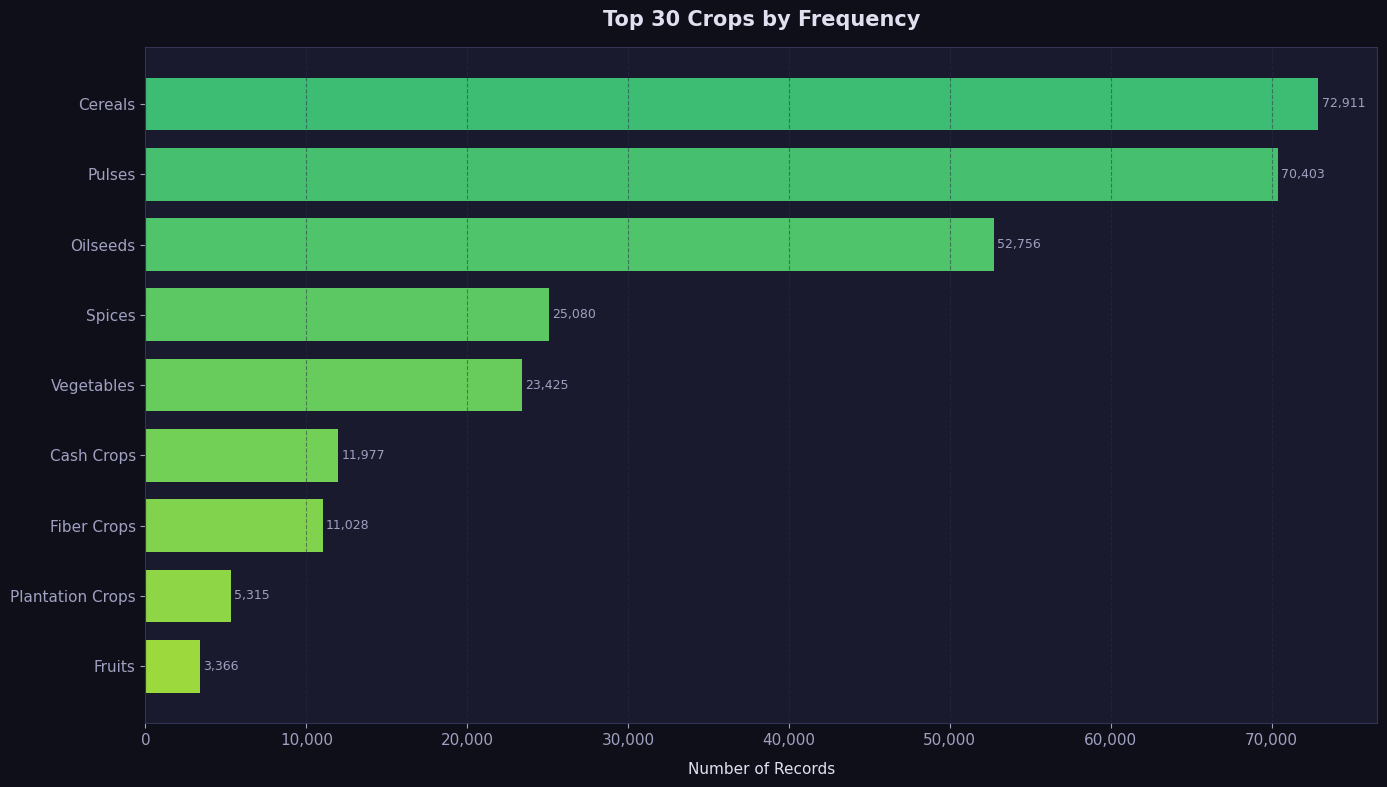

In [41]:
# Top 30 crops bar chart
top_n = 30
top_crops = crop_cat_counts.head(top_n)

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0.85, 0.25, top_n))
bars = ax.barh(top_crops.index[::-1], top_crops.values[::-1], color=colors, edgecolor='none', height=0.75)

for bar, val in zip(bars, top_crops.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=9, color='#a0a0c0')

ax.set_xlabel('Number of Records', labelpad=10)
ax.set_title(f'Top {top_n} Crops by Frequency', fontsize=15, pad=15, color='#e0e0f0', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
plt.tight_layout()
plt.show()

3 crops account for 80% of all records  (out of 9 total crops)


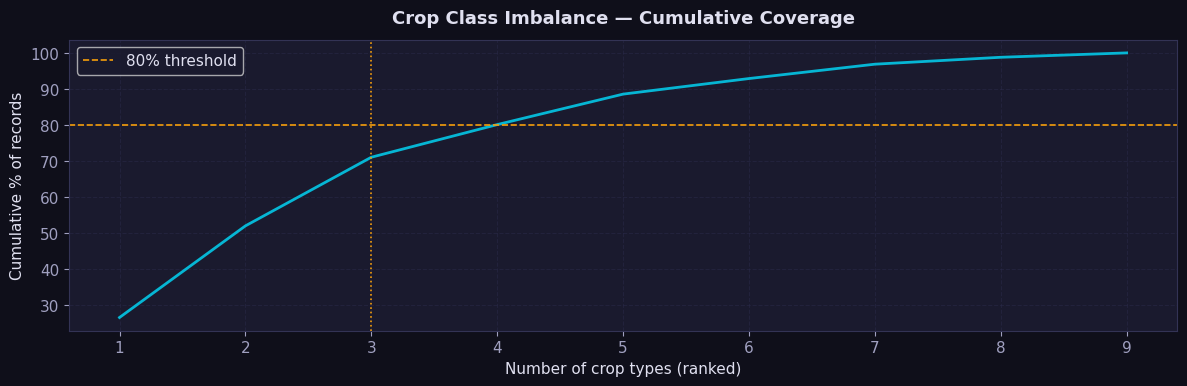

In [42]:
# Long tail analysis: % of crops that cover 80% of records
cum_pct = crop_cat_counts.cumsum() / crop_cat_counts.sum() * 100
crops_80 = (cum_pct <= 80).sum()
print(f'{crops_80} crops account for 80% of all records  (out of {len(crop_cat_counts)} total crops)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(cum_pct)+1), cum_pct.values, color=ACCENT2, linewidth=2)
ax.axhline(80, color=HIGHLIGHT, linestyle='--', linewidth=1.2, label='80% threshold')
ax.axvline(crops_80, color=HIGHLIGHT, linestyle=':', linewidth=1.2)
ax.set_xlabel('Number of crop types (ranked)')
ax.set_ylabel('Cumulative % of records')
ax.set_title('Crop Class Imbalance — Cumulative Coverage', fontsize=13, fontweight='bold', pad=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7. Season Distribution

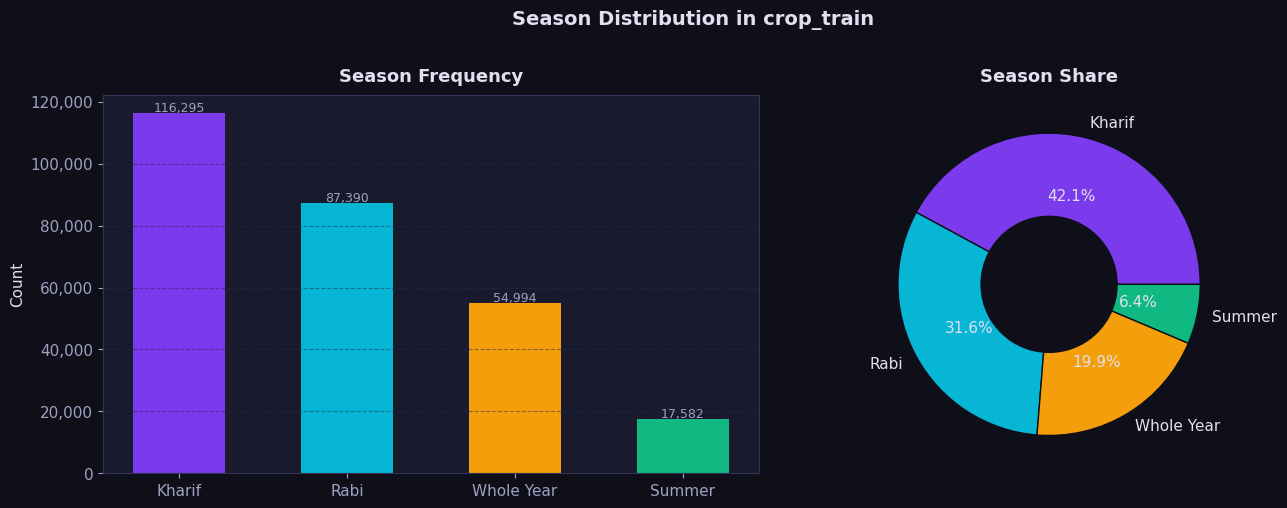

In [43]:
season_counts = train['Season'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_s = [ACCENT, ACCENT2, HIGHLIGHT, '#10b981', '#f43f5e']
axes[0].bar(season_counts.index, season_counts.values,
            color=colors_s[:len(season_counts)], edgecolor='none', width=0.55)
for i, (s, v) in enumerate(season_counts.items()):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9, color='#a0a0c0')
axes[0].set_title('Season Frequency', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='y')

# Pie chart
wedge_props = dict(width=0.55, edgecolor='#0f0f1a')
axes[1].pie(season_counts.values, labels=season_counts.index,
            autopct='%1.1f%%', colors=colors_s[:len(season_counts)],
            wedgeprops=wedge_props, textprops={'color': '#e0e0f0'})
axes[1].set_title('Season Share', fontsize=13, fontweight='bold', pad=10)

fig.suptitle('Season Distribution in crop_train', fontsize=14, y=1.01, color='#e0e0f0', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. State Distribution

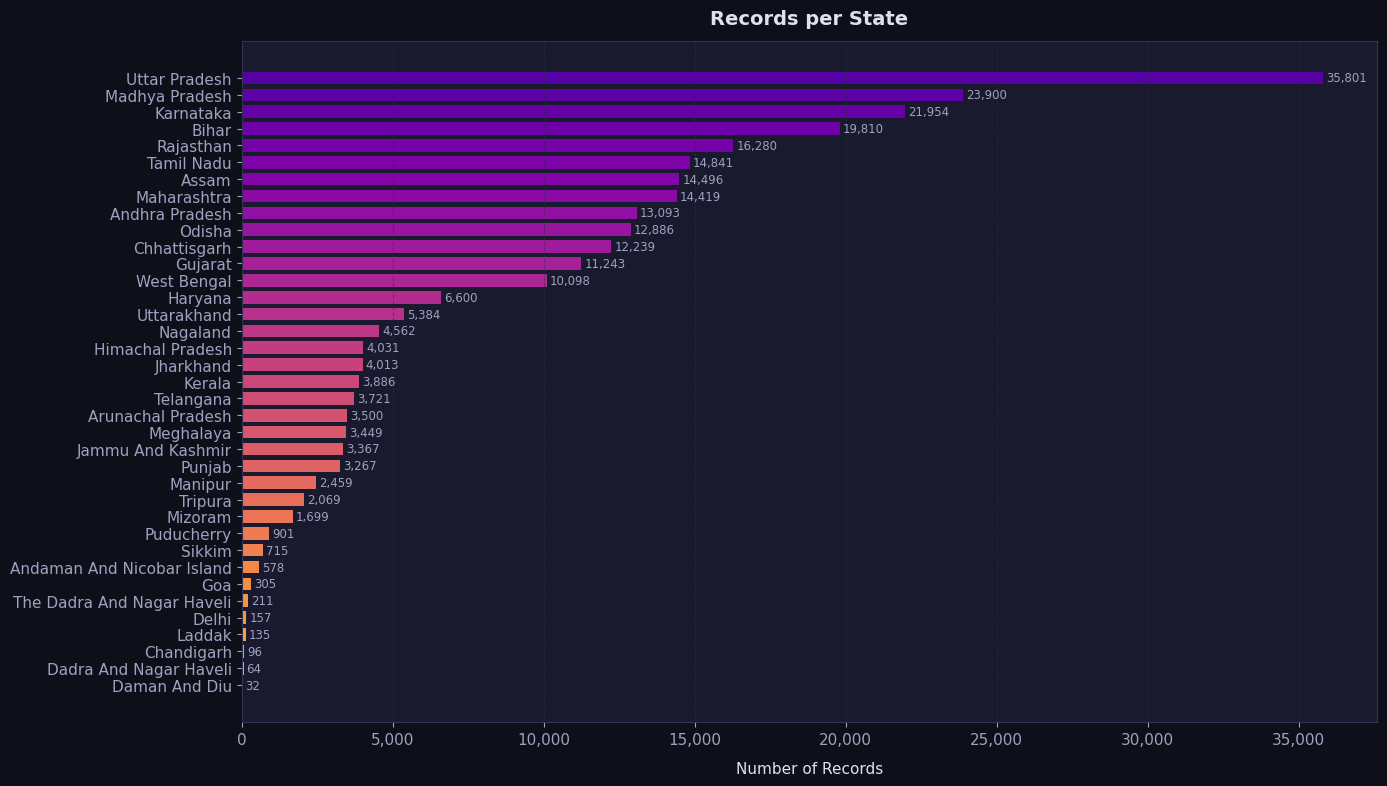

In [44]:
state_counts = train['State'].value_counts()

fig, ax = plt.subplots(figsize=(14, 8))
colors_state = plt.cm.plasma(np.linspace(0.85, 0.15, len(state_counts)))
ax.barh(state_counts.index[::-1], state_counts.values[::-1], color=colors_state, edgecolor='none', height=0.75)

for i, val in enumerate(state_counts.values[::-1]):
    ax.text(val + 100, i, f'{val:,}', va='center', fontsize=8.5, color='#a0a0c0')

ax.set_xlabel('Number of Records', labelpad=10)
ax.set_title('Records per State', fontsize=14, pad=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 9. Year Distribution

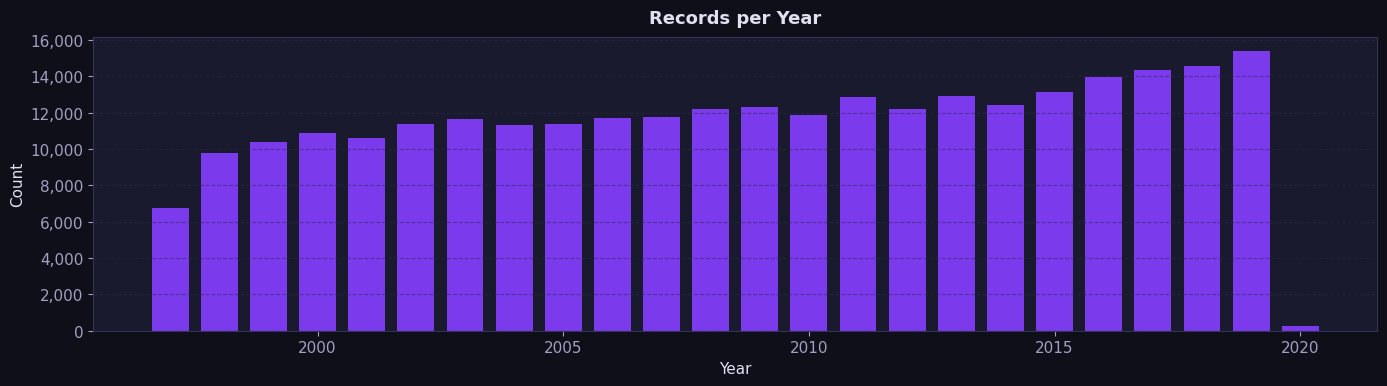

In [45]:
year_counts = train['Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color=ACCENT, edgecolor='none', width=0.75)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Records per Year', fontsize=13, fontweight='bold', pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## 10. Crop × Season Heatmap (Top 20 Crops)

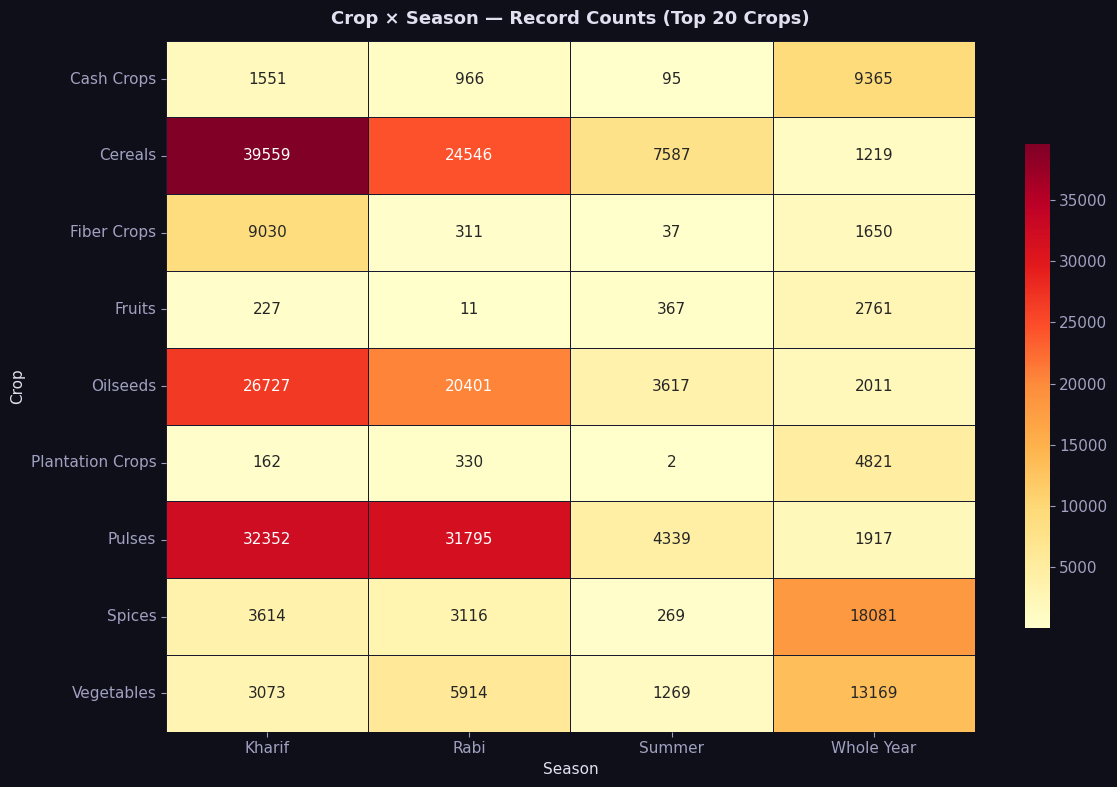

In [46]:
top20_crops = crop_cat_counts.head(20).index.tolist()
subset = train[train['Crop_Category'].isin(top20_crops)]

pivot = subset.groupby(['Crop_Category', 'Season']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='#1a1a2e',
            cbar_kws={'shrink': 0.7},
            ax=ax)
ax.set_title('Crop × Season — Record Counts (Top 20 Crops)', fontsize=13, pad=12, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Crop')
plt.tight_layout()
plt.show()

## 11. Top 5 Crops per Season

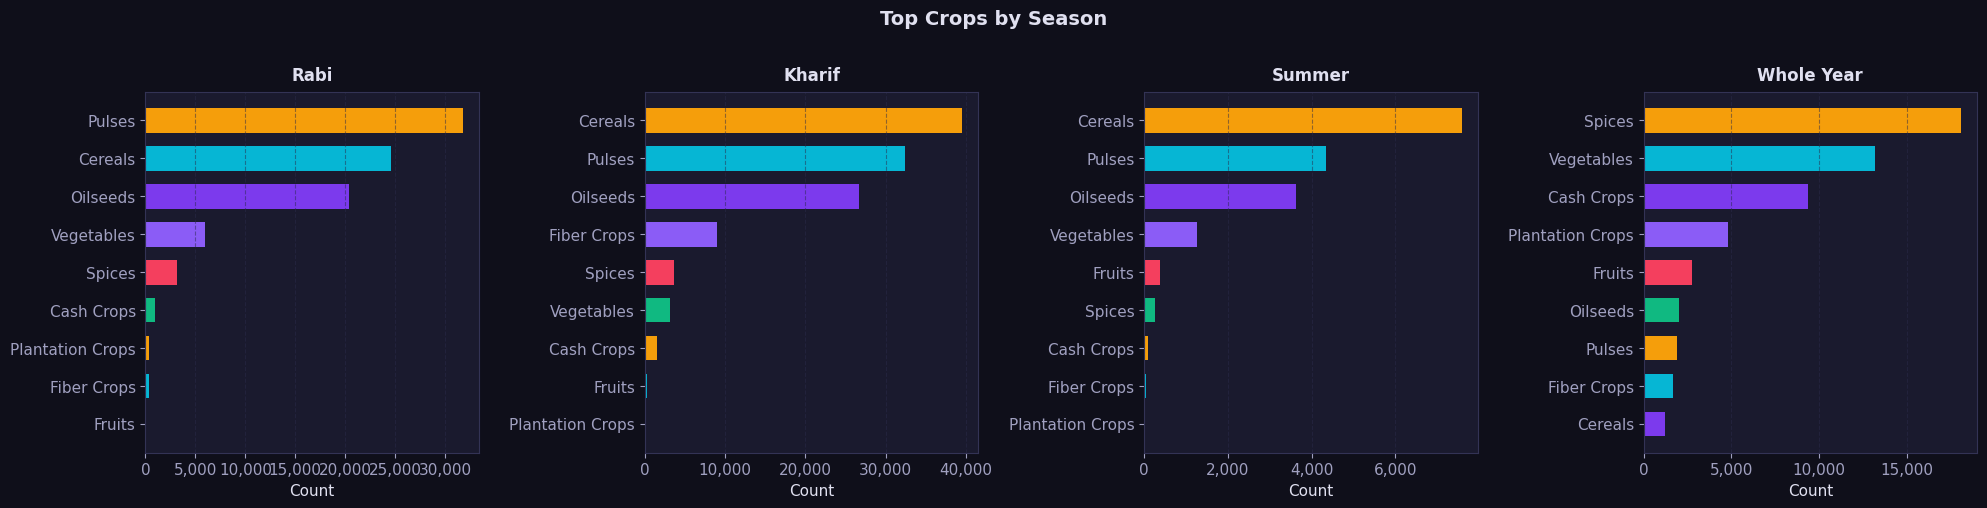

In [47]:
seasons = train['Season'].unique()
n_seasons = len(seasons)

fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 5), sharey=False)
if n_seasons == 1:
    axes = [axes]

palette_list = [ACCENT, ACCENT2, HIGHLIGHT, '#10b981', '#f43f5e', '#8b5cf6']

for ax, season in zip(axes, seasons):
    data = train[train['Season'] == season]['Crop_Category'].value_counts().head(10)
    ax.barh(data.index[::-1], data.values[::-1],
            color=palette_list[:len(data)], edgecolor='none', height=0.65)
    ax.set_title(f'{season}', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Count')
    ax.grid(axis='x')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Top Crops by Season', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 12. Top 5 Crops per State (Top 10 States)

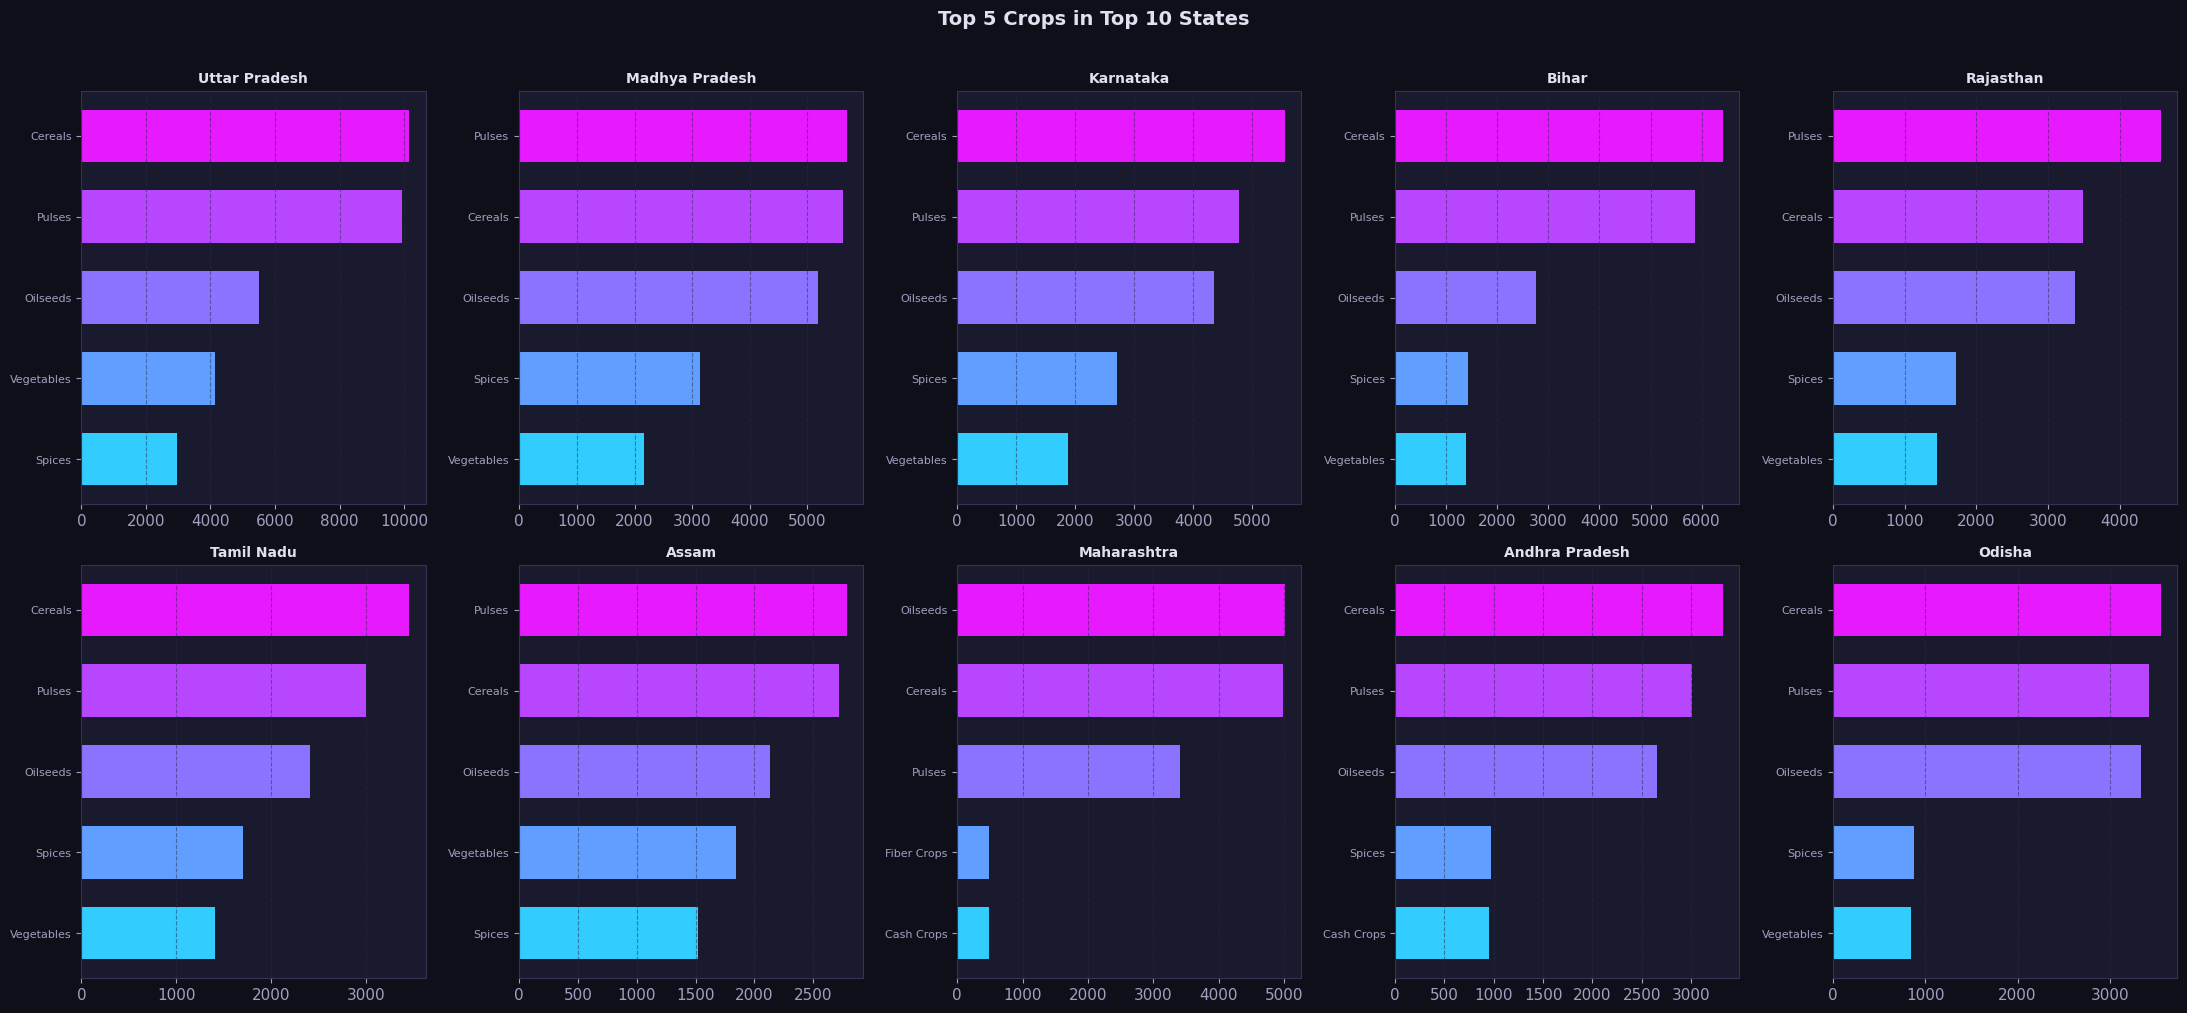

In [48]:
top10_states = state_counts.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for ax, state in zip(axes, top10_states):
    data = train[train['State'] == state]['Crop_Category'].value_counts().head(5)
    colors_c = plt.cm.cool(np.linspace(0.2, 0.9, len(data)))
    ax.barh(data.index[::-1], data.values[::-1], color=colors_c, edgecolor='none', height=0.65)
    ax.set_title(state, fontsize=10, fontweight='bold', pad=6)
    ax.grid(axis='x')
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Top 5 Crops in Top 10 States', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13. Crop Diversity per State

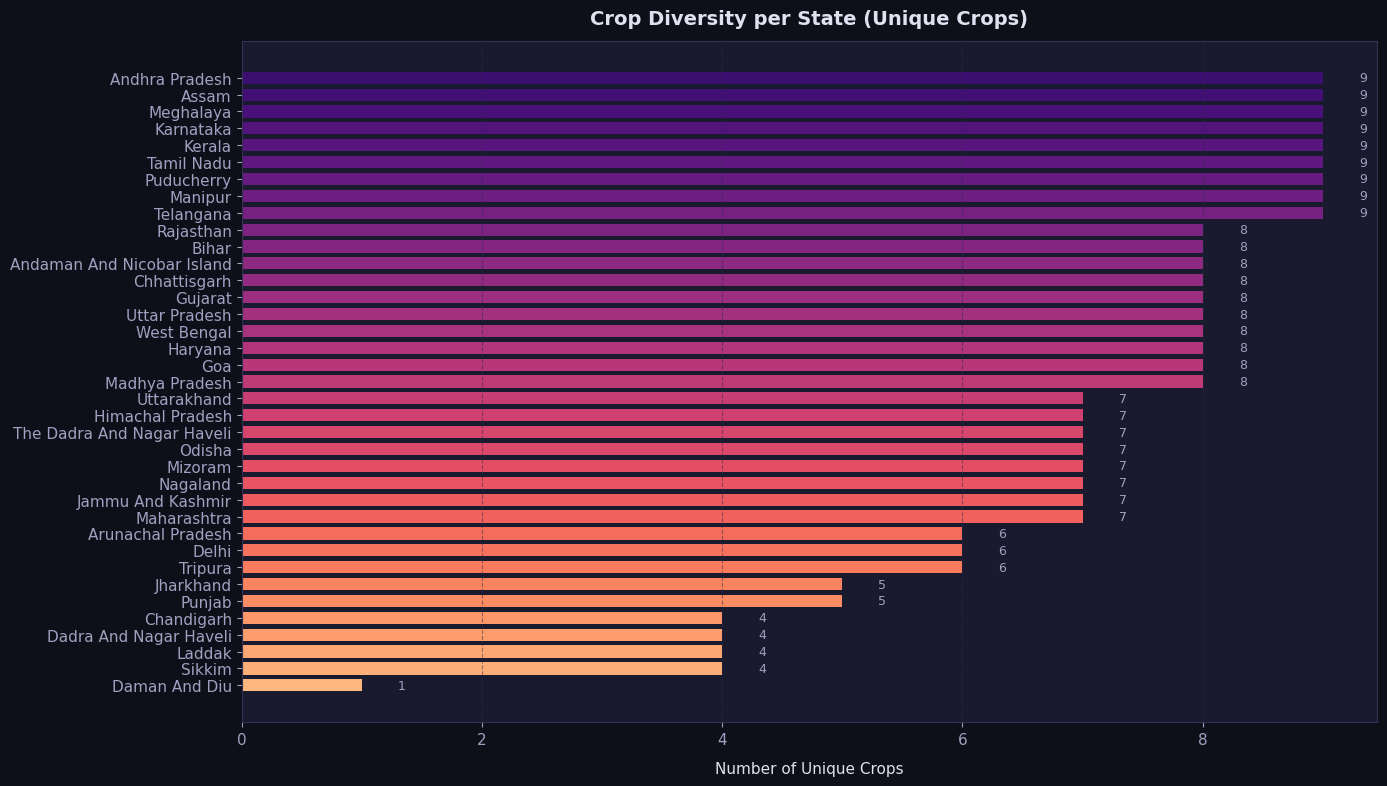

In [49]:
crop_diversity = train.groupby('State')['Crop_Category'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors_d = plt.cm.magma(np.linspace(0.85, 0.2, len(crop_diversity)))
ax.barh(crop_diversity.index[::-1], crop_diversity.values[::-1], color=colors_d, edgecolor='none', height=0.72)

for i, val in enumerate(crop_diversity.values[::-1]):
    ax.text(val + 0.3, i, str(val), va='center', fontsize=9, color='#a0a0c0')

ax.set_xlabel('Number of Unique Crops', labelpad=10)
ax.set_title('Crop Diversity per State (Unique Crops)', fontsize=14, pad=12, fontweight='bold')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 14. Year Trend — Records over Time

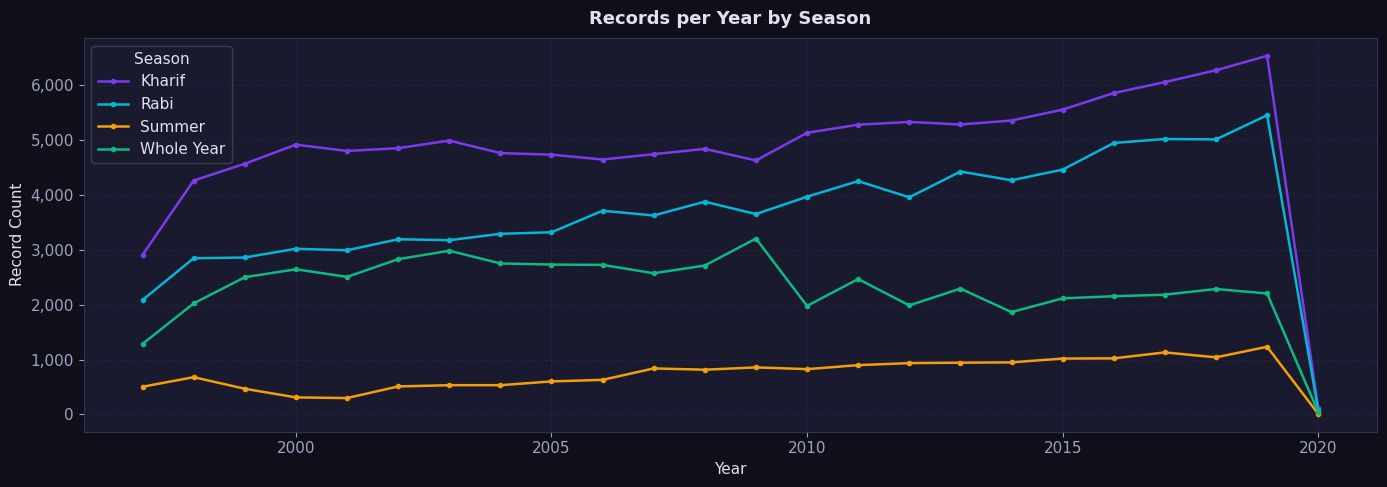

In [50]:
year_season = train.groupby(['Year', 'Season']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
season_colors = [ACCENT, ACCENT2, HIGHLIGHT, '#10b981']
for i, col in enumerate(year_season.columns):
    ax.plot(year_season.index, year_season[col], marker='o', markersize=3,
            color=season_colors[i % len(season_colors)], linewidth=1.8, label=col)

ax.set_xlabel('Year')
ax.set_ylabel('Record Count')
ax.set_title('Records per Year by Season', fontsize=13, fontweight='bold', pad=10)
ax.legend(title='Season', framealpha=0.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True)
plt.tight_layout()
plt.show()

## 15. Class Balance Summary

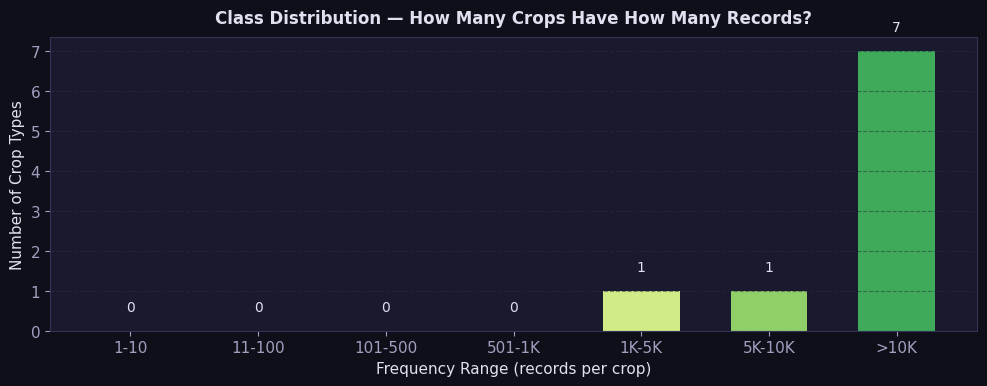


Summary:
         Crop Types
count              
1-10              0
11-100            0
101-500           0
501-1K            0
1K-5K             1
5K-10K            1
>10K              7


In [51]:
crop_freq = train['Crop_Category'].value_counts()

bins = [1, 10, 100, 500, 1000, 5000, 10000, np.inf]
labels = ['1-10', '11-100', '101-500', '501-1K', '1K-5K', '5K-10K', '>10K']
freq_bins = pd.cut(crop_freq, bins=bins, labels=labels, right=True)
bin_summary = freq_bins.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(bin_summary)))
ax.bar(bin_summary.index, bin_summary.values, color=bar_colors, edgecolor='none', width=0.6)
for i, v in enumerate(bin_summary.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10, color='#e0e0f0')
ax.set_xlabel('Frequency Range (records per crop)')
ax.set_ylabel('Number of Crop Types')
ax.set_title('Class Distribution — How Many Crops Have How Many Records?', fontsize=12, fontweight='bold', pad=10)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print('\nSummary:')
print(pd.DataFrame({'Crop Types': bin_summary}))

## 16. District — Top 20

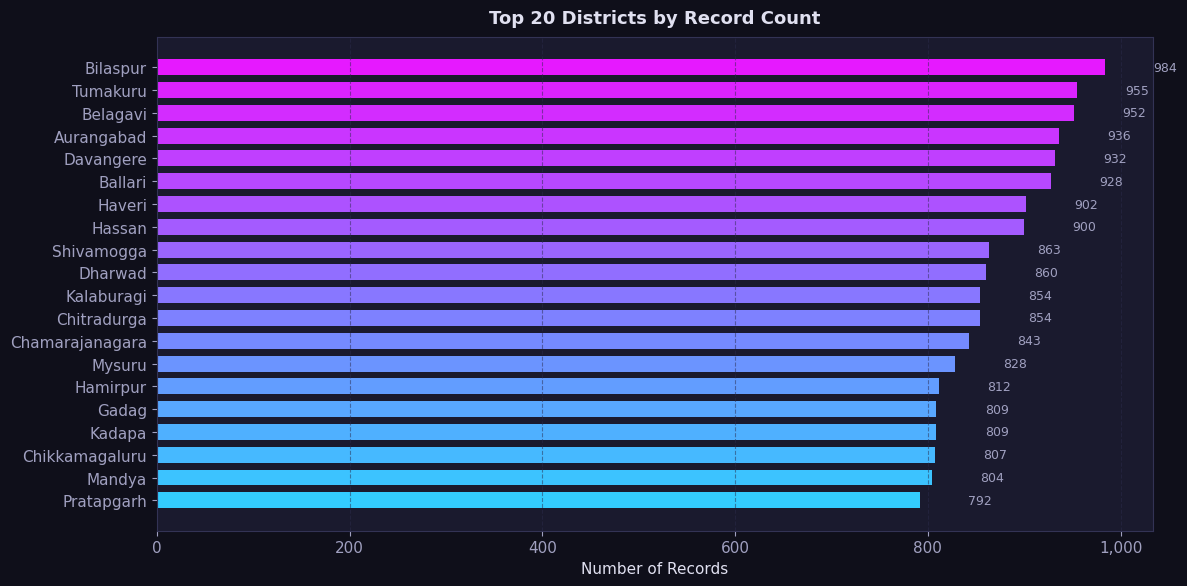

In [52]:
dist_counts = train['District'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
colors_dist = plt.cm.cool(np.linspace(0.2, 0.9, len(dist_counts)))
ax.barh(dist_counts.index[::-1], dist_counts.values[::-1], color=colors_dist, edgecolor='none', height=0.7)
for i, val in enumerate(dist_counts.values[::-1]):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=9, color='#a0a0c0')
ax.set_xlabel('Number of Records')
ax.set_title('Top 20 Districts by Record Count', fontsize=13, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 17. Top 3 Crop Categories by State–District–Season

In [53]:
# Top 3 crop categories for every State-District-Season combination

top3_categories = (
    train.groupby(['State', 'District', 'Season', 'Crop_Category'])
         .size()
         .reset_index(name='Count')
)

top3_categories['Rank'] = (
    top3_categories.groupby(['State', 'District', 'Season'])['Count']
                   .rank(method='first', ascending=False)
)

top3_categories = (
    top3_categories[top3_categories['Rank'] <= 3]
    .sort_values(['State', 'District', 'Season', 'Rank'])
)

top3_categories.head(20)

,State,District,Season,Crop_Category,Count,Rank
1,Andaman And Nicobar Island,Nicobars,Kharif,Cereals,15,1.0
0,Andaman And Nicobar Island,Nicobars,Kharif,Cash Crops,10,2.0
2,Andaman And Nicobar Island,Nicobars,Kharif,Fruits,3,3.0
11,Andaman And Nicobar Island,Nicobars,Rabi,Spices,31,1.0
9,Andaman And Nicobar Island,Nicobars,Rabi,Plantation Crops,17,2.0
10,Andaman And Nicobar Island,Nicobars,Rabi,Pulses,10,3.0
19,Andaman And Nicobar Island,Nicobars,Summer,Vegetables,4,1.0
17,Andaman And Nicobar Island,Nicobars,Summer,Pulses,3,2.0
18,Andaman And Nicobar Island,Nicobars,Summer,Spices,3,3.0
23,Andaman And Nicobar Island,Nicobars,Whole Year,Plantation Crops,30,1.0


In [54]:
top3_categories[
    (top3_categories['State'] == 'Gujarat') &
    (top3_categories['District'] == 'Surendranagar') &
    (top3_categories['Season'] == 'Kharif')
]



,State,District,Season,Crop_Category,Count,Rank
3025,Gujarat,Surendranagar,Kharif,Pulses,76,1.0
3024,Gujarat,Surendranagar,Kharif,Oilseeds,58,2.0
3022,Gujarat,Surendranagar,Kharif,Cereals,44,3.0


## 18. Top 3 Crops inside every Category

In [55]:
# Top 3 crops inside every State-District-Season-Category

top3_crops = (
    train.groupby(
        ['State','District','Season',
         'Crop_Category','Crop']
    )
    .size()
    .reset_index(name='Count')
)

top3_crops['Rank'] = (
    top3_crops.groupby(
        ['State','District','Season','Crop_Category']
    )['Count']
    .rank(method='first', ascending=False)
)

top3_crops = (
    top3_crops[top3_crops['Rank'] <= 3]
    .sort_values(
        ['State','District','Season',
         'Crop_Category','Rank']
    )
)

top3_crops.head(20)

,State,District,Season,Crop_Category,Crop,Count,Rank
0,Andaman And Nicobar Island,Nicobars,Kharif,Cash Crops,Sugarcane,10,1.0
1,Andaman And Nicobar Island,Nicobars,Kharif,Cereals,Rice,15,1.0
2,Andaman And Nicobar Island,Nicobars,Kharif,Fruits,Banana,3,1.0
3,Andaman And Nicobar Island,Nicobars,Kharif,Plantation Crops,Arecanut,1,1.0
4,Andaman And Nicobar Island,Nicobars,Kharif,Pulses,Other Kharif pulses,2,1.0
5,Andaman And Nicobar Island,Nicobars,Kharif,Spices,Dry chillies,1,1.0
6,Andaman And Nicobar Island,Nicobars,Kharif,Vegetables,Sweet potato,1,1.0
7,Andaman And Nicobar Island,Nicobars,Kharif,Vegetables,Tapioca,1,2.0
8,Andaman And Nicobar Island,Nicobars,Rabi,Cereals,Maize,4,1.0
9,Andaman And Nicobar Island,Nicobars,Rabi,Fruits,Banana,1,1.0


In [74]:
top3_crops[
    (top3_crops['State']=='Gujarat') &
    (top3_crops['District']=='Surendranagar') &
    (top3_crops['Season']=='Kharif') &
    (top3_crops['Crop_Category']=='Fiber Crops')
]

,State,District,Season,Crop_Category,Crop,Count,Rank
7885,Gujarat,Surendranagar,Kharif,Fiber Crops,Cotton(lint),16,1.0


## 19. Historical Probability Table

In [62]:
def category_probability(state, district, season):
    
    df = train[
        (train['State']==state) &
        (train['District']==district) &
        (train['Season']==season)
    ]
    
    out = (
        df['Crop_Category']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename_axis('Category')
        .reset_index(name='Probability (%)')
    )
    
    return out

In [73]:
category_probability(
    'Gujarat',
    'Surendranagar',
    'Kharif'
)

,Category,Probability (%)
0,Pulses,39.18
1,Oilseeds,29.90
2,Cereals,22.68
3,Fiber Crops,8.25


## 20. Crop Probability Table

In [69]:
def crop_probability(state,
                     district,
                     season,
                     category):
    
    df = train[
        (train['State']==state) &
        (train['District']==district) &
        (train['Season']==season) &
        (train['Crop_Category']==category)
    ]
    
    out = (
        df['Crop']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename_axis('Crop')
        .reset_index(name='Probability (%)')
    )
    
    return out


crop_probability(
    'Gujarat',
    'Rajkot',
    'Kharif',
    'Oilseeds'
)

,Crop,Probability (%)
0,Sesamum,31.75
1,Groundnut,30.16
2,Castor seed,26.98
3,Soyabean,9.52
4,other oilseeds,1.59


## 21. Visualization (Highly Recommended)

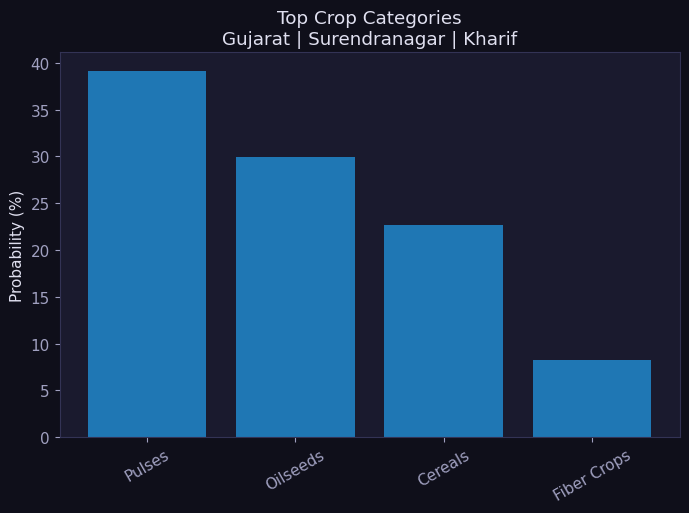

In [72]:
state = 'Gujarat'
district = 'Surendranagar'
season = 'Kharif'

temp = category_probability(state, district, season)

plt.figure(figsize=(8,5))

plt.bar(
    temp['Category'],
    temp['Probability (%)']
)

plt.title(
    f'Top Crop Categories\n{state} | {district} | {season}'
)

plt.ylabel('Probability (%)')

plt.xticks(rotation=30)

plt.show()

## 22. Crop Recommendation Plot

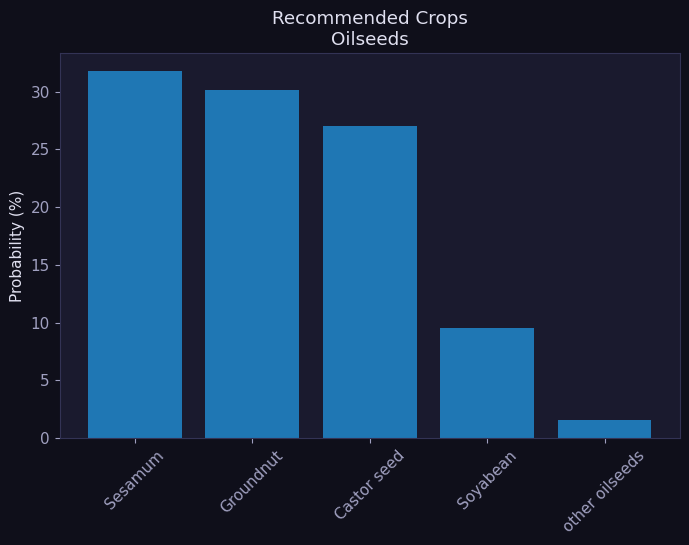

In [75]:
state='Gujarat'
district='Rajkot'
season='Kharif'
category='Oilseeds'

temp = crop_probability(
    state,
    district,
    season,
    category
)

plt.figure(figsize=(8,5))

plt.bar(
    temp['Crop'],
    temp['Probability (%)']
)

plt.title(
    f'Recommended Crops\n{category}'
)

plt.ylabel('Probability (%)')

plt.xticks(rotation=45)

plt.show()

## 23. EDA Summary

In [56]:
print('=' * 55)
print('         CROP EDA — KEY FINDINGS')
print('=' * 55)
print(f'  Total train records  : {len(train):,}')
print(f'  Total test  records  : {len(test):,}')
print(f'  Unique Crops         : {train["Crop_Category"].nunique()}')
print(f'  Unique States        : {train["State"].nunique()}')
print(f'  Unique Districts     : {train["District"].nunique()}')
print(f'  Unique Seasons       : {train["Season"].nunique()}')
print(f'  Year range           : {train["Year"].min()} – {train["Year"].max()}')
print(f'  Missing values       : {train.isnull().sum().sum()}')
print(f'  Most common crop     : {train["Crop_Category"].value_counts().idxmax()}')
print(f'  Most common season   : {train["Season"].value_counts().idxmax()}')
print(f'  Most common state    : {train["State"].value_counts().idxmax()}')
print('=' * 55)

         CROP EDA — KEY FINDINGS
  Total train records  : 276,261
  Total test  records  : 69,066
  Unique Crops         : 9
  Unique States        : 37
  Unique Districts     : 707
  Unique Seasons       : 4
  Year range           : 1997 – 2020
  Missing values       : 0
  Most common crop     : Cereals
  Most common season   : Kharif
  Most common state    : Uttar Pradesh


In [57]:
combo = (
    train.groupby(
        ['State', 'District', 'Season', 'Year']
    )['Crop_Category']
    .nunique()
)

print(combo.describe())

count    44208.000000
mean         3.161894
std          1.431197
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          9.000000
Name: Crop_Category, dtype: float64


In [58]:
combo.value_counts().sort_index()

Crop_Category
1     6845
2     6855
3    13198
4    10100
5     5004
6     1496
7      514
8      126
9       70
Name: count, dtype: int64